# LifeGPT Inference Demo

Loads the best-performing model (broad-entropy, FCM, epoch 50), runs one Game of Life step exactly via the rules, and compares against the model's prediction.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from x_transformers import TransformerWrapper, Decoder
from x_transformers.autoregressive_wrapper import AutoregressiveWrapper
import typing

# Ensure Torch is using Cuda
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [2]:
NUM_WORDS=256

MAX_LENGTH = len("@PredictNextState<> []$") + (32*32*2)  # 2071
GENERATE_LENGTH = MAX_LENGTH - len("@PredictNextState<>") - (32 * 32)  # 1028

GRID_SIZE = 32

## 1. Initialize modules and relevant functions

In [3]:
class Tokenizer:
    def __init__(self, n_pad: int, device: torch.device, pad_byte: int = 0):
        self.n_pad = n_pad
        self.device = device
        self.pad_byte = pad_byte

    def tokenize_str(self, sentence: str, encoding="utf8", do_padding=True):
        base = list(bytes(sentence, encoding))
        if do_padding:
            if len(base) < self.n_pad:
                base.extend([self.pad_byte] * (self.n_pad - len(base)))
            assert len(base) == self.n_pad, f"n_pad is too small, use {len(base)} or greater."
        tensor = torch.Tensor(base)
        return tensor.long().to(self.device)

    def texts_to_sequences(self, texts: typing.List[str], encoding="utf8", do_padding=True):
        sentences = [self.tokenize_str(sentence, do_padding=do_padding).unsqueeze(0) for sentence in texts]
        return torch.cat(sentences, dim=0).to(self.device)

    def sequences_to_texts(self, texts: torch.Tensor, encoding="utf8"):
        out = []
        for seq in texts:
            chars = []
            i = 0
            while i < len(seq) and seq[i] != 0:
                chars.append(int(seq[i]))
                i += 1
            try:
                out.append(bytes(chars).decode(encoding))
            except:
                pass
        return out

def empty_cuda_cache():
    torch.cuda.empty_cache()

def extract_sample(string_input, start_token='[', end_token=']'):
    i = string_input.find(start_token)
    j = string_input.find(end_token)
    return string_input[i+1:j]

def extract_task(string_input, end_task_token='>'):
    j = string_input.find(end_task_token)
    return string_input[:j+1]


# 2. Define `load_model` function

In [4]:
def load_model(model_path, max_length, num_words):
    empty_cuda_cache()
    
    model = TransformerWrapper(
        num_tokens=num_words,
        max_seq_len=max_length,
        attn_layers=Decoder(
            dim=256,
            depth=12,
            heads=8,
            attn_dim_head=64,
            rotary_pos_emb=True,
            attn_flash=True
        )
    )
    model = AutoregressiveWrapper(model)
    model.load_state_dict(torch.load(model_path))
    model.to(device)
    print(f"Model loaded from {model_path}")
    
    return model

# 3. Load the model

In [5]:
model_path = f"../model_parameters/07_22_2024_Conway_2_State_Jump_Rot_Pos_On_Masking_On_Broad_Entropy_Homog_2024-07-23 10-37-31/LifeGPT_epoch_50.pt"
# model_path = "../model_parameters/08_14_2024_Conway_2_State_Jump_Rot_Pos_On_Masking_Off_High_Entropy_Homog_2024-08-14 12-24-10/LifeGPT_epoch_16.pt"
model = load_model(model_path, MAX_LENGTH, NUM_WORDS)

Model loaded from ../model_parameters/07_22_2024_Conway_2_State_Jump_Rot_Pos_On_Masking_On_Broad_Entropy_Homog_2024-07-23 10-37-31/LifeGPT_epoch_50.pt


In [6]:
tokenizer = Tokenizer(MAX_LENGTH, device)

## 2. Hardcoded initial state

We place two classic patterns on a 32×32 toroidal grid:
- a **Gosper glider gun** (top-left region)
- a **blinker** (bottom-right region)

This gives a visually varied initial condition without loading any data files.

In [7]:
grid_init = np.zeros((GRID_SIZE, GRID_SIZE), dtype=np.int32)

# --- Glider (top-left, row-offset=2, col-offset=2) ---
#  .O.
#  ..O
#  OOO
glider_cells = [(0,1),(1,2),(2,0),(2,1),(2,2)]
for r, c in glider_cells:
    grid_init[r + 2, c + 2] = 1

# --- Blinker (bottom-right, vertical orientation) ---
#  O
#  O
#  O
blinker_cells = [(0,0),(1,0),(2,0)]
for r, c in blinker_cells:
    grid_init[r + 26, c + 26] = 1

# --- R-pentomino (centre) ---
#  .OO
#  OO.
#  .O.
rpent_cells = [(0,1),(0,2),(1,0),(1,1),(2,1)]
for r, c in rpent_cells:
    grid_init[r + 14, c + 14] = 1

print(f"Live cells: {grid_init.sum()}")

Live cells: 13


## 3. Compute the exact next state using Game of Life rules

In [8]:
def gol_step(grid: np.ndarray) -> np.ndarray:
    """One GoL step with toroidal (periodic) boundary conditions."""
    neighbors = sum(
        np.roll(np.roll(grid, dr, axis=0), dc, axis=1)
        for dr in [-1, 0, 1]
        for dc in [-1, 0, 1]
        if not (dr == 0 and dc == 0)
    )
    return ((neighbors == 3) | (grid.astype(bool) & (neighbors == 2))).astype(np.int32)

grid_exact = gol_step(grid_init)
print(f"Live cells after one step: {grid_exact.sum()}")

Live cells after one step: 14


## 4. Plot: initial state vs. exact next state

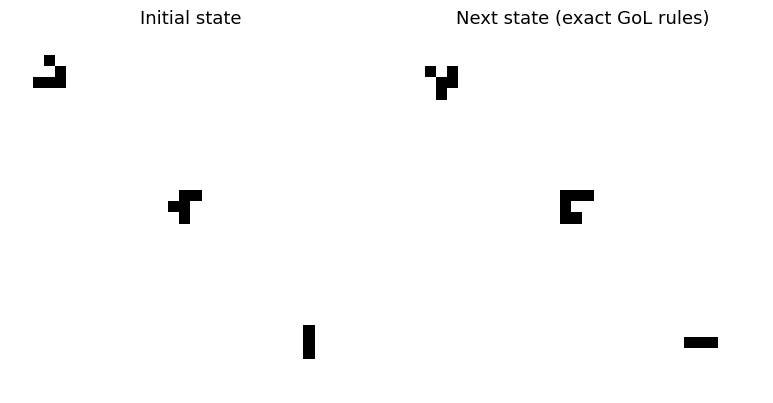

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(grid_init,  cmap="binary", vmin=0, vmax=1)
axes[0].set_title("Initial state", fontsize=13)
axes[0].axis("off")

axes[1].imshow(grid_exact, cmap="binary", vmin=0, vmax=1)
axes[1].set_title("Next state (exact GoL rules)", fontsize=13)
axes[1].axis("off")

plt.tight_layout()
plt.show()

## 5. Convert the initial state to the model's input format

The model expects a byte-tokenised ASCII string of the form:
```
@PredictNextState<{1024 bits}>
```
Grid cells are flattened row-major as '0'/'1' characters.

In [10]:
# Flatten the grid to a binary string and wrap in the prompt format
state_str  = "".join(str(int(cell)) for cell in grid_init.flatten())
input_seq = f"@PredictNextState<{state_str}>"

print(f"Prompt length : {len(input_seq)} chars")
print(f"Prompt preview: {input_seq[:40]}...{input_seq[-10:]}")

Prompt length : 1043 chars
Prompt preview: @PredictNextState<0000000000000000000000...000000000>


## 6. Run the model to predict the next state

In [11]:
inp = extract_task(input_seq, end_task_token='>')
inp = torch.Tensor(tokenizer.texts_to_sequences(inp, do_padding=False)).to(device)
inp = inp.transpose(0, 1)
inp = inp.long()
print(f"inp.shape: {inp.shape}")

inp.shape: torch.Size([1, 1043])


In [12]:
with torch.no_grad():
    sample = model.generate(
        prompts=inp,
        seq_len=GENERATE_LENGTH,
        temperature=0,
        cache_kv=True
    )

print(sample.shape)

try:
    output_str = tokenizer.sequences_to_texts(sample[:1])
    pred_str = extract_sample(output_str[0])
    print(f"Prediction: {pred_str}")

except Exception as e:
    print(f"Error decoding output: {e}")

/opt/conda/envs/LifeGPT_env/lib/python3.10/site-packages/torch/backends/cuda/__init__.py:342: FutureWarning: torch.backends.cuda.sdp_kernel() is deprecated. In the future, this context manager will be removed. Please see, torch.nn.attention.sdpa_kernel() for the new context manager, with updated signature.
  warnings.warn(


torch.Size([1, 1028])
Prediction: 000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000001010000000000000000000000000000001100000000000000000000000000000010000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000111000000000000000000000000000001000000000000000000000000000000011000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000000011100000000000000000000000000000000000000000000000000000000000000000000000000

In [13]:
if pred_str and len(pred_str) == GRID_SIZE * GRID_SIZE:
    grid_pred = np.array([int(b) for b in pred_str], dtype=np.int32).reshape(GRID_SIZE, GRID_SIZE)
    print(f"Prediction decoded successfully. Live cells: {grid_pred.sum()}")
else:
    print(f"Decode failed or wrong length (got {len(pred_str) if pred_str else 'None'} bits).")
    grid_pred = None

Prediction decoded successfully. Live cells: 14


## 7. Plot: exact next state vs. model prediction

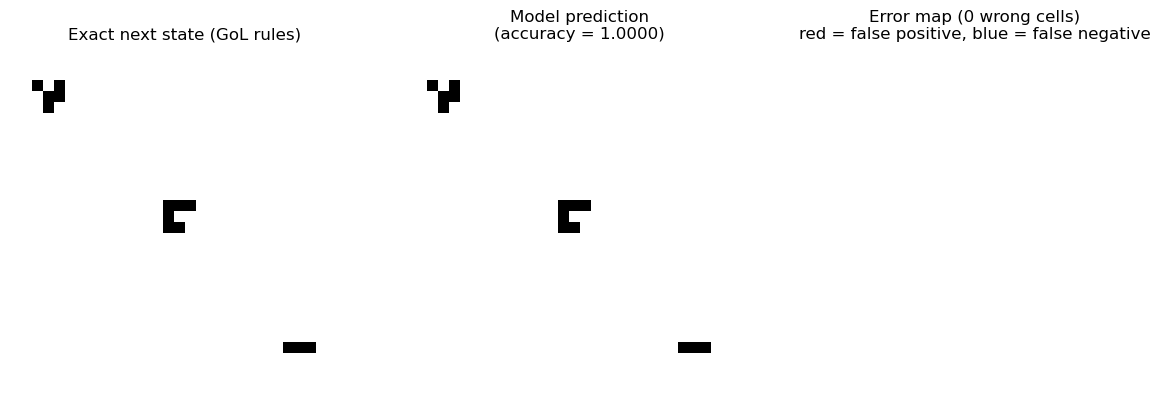

In [14]:
if grid_pred is not None:
    # Per-cell accuracy
    n_cells    = GRID_SIZE * GRID_SIZE
    n_correct  = int((grid_exact == grid_pred).sum())
    accuracy   = n_correct / n_cells
    n_wrong    = n_cells - n_correct

    # Difference map: +1 = model predicts live but dead, -1 = model predicts dead but live
    diff = grid_pred.astype(int) - grid_exact.astype(int)

    fig, axes = plt.subplots(1, 3, figsize=(12, 4))

    axes[0].imshow(grid_exact, cmap="binary", vmin=0, vmax=1)
    axes[0].set_title("Exact next state (GoL rules)", fontsize=12)
    axes[0].axis("off")

    axes[1].imshow(grid_pred, cmap="binary", vmin=0, vmax=1)
    axes[1].set_title(f"Model prediction\n(accuracy = {accuracy:.4f})", fontsize=12)
    axes[1].axis("off")

    # Colour-code errors: red = false positive, blue = false negative
    diff_rgb = np.ones((*diff.shape, 3))   # white background
    diff_rgb[diff ==  1] = [1.0, 0.2, 0.2]  # model says live, truth says dead → red
    diff_rgb[diff == -1] = [0.2, 0.4, 1.0]  # model says dead, truth says live → blue
    axes[2].imshow(diff_rgb)
    axes[2].set_title(
        f"Error map ({n_wrong} wrong cells)\n"
        f"red = false positive, blue = false negative",
        fontsize=12,
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print("Cannot plot: model output could not be decoded.")